# Image Classification (SVC & XGBoost)

[Dataset](https://www.kaggle.com/datasets/iasadpanwhar/parking-lot-detection-counter)

## **Imports**

In [3]:
import os
import numpy as np

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

from sklearn.metrics import classification_report
import pickle

from xgboost import XGBClassifier

# ***Parking Lot***

## **Load Data & Prepare**

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iasadpanwhar/parking-lot-detection-counter")

print("Path to dataset files:", path)

100%|██████████| 250M/250M [00:11<00:00, 21.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/iasadpanwhar/parking-lot-detection-counter/versions/1


In [24]:
!mv /root/.cache/kagglehub/datasets/iasadpanwhar/parking-lot-detection-counter/versions/1/parking /content/

In [25]:
input_root_dir = "/content/parking"
input_dir = os.path.join(input_root_dir, "clf-data")
categories = ["empty", "not_empty"]

In [26]:
data = []
labels = []

for cat_idx, cat in enumerate(categories):
    for file_name in os.listdir(os.path.join(input_dir, cat)):
        img_path = os.path.join(input_dir, cat, file_name)
        img = imread(img_path)
        # print(img.shape) # (29, 60, 3)
        img = resize(img, (15, 15)) # 15, 30?
        data.append(img.flatten())
        labels.append(cat_idx)

Convert to numpy array

In [27]:
data = np.array(data)
labels = np.array(labels)

## **Split train & test**

In train_test_split, the **stratify** parameter ensures that the training and testing sets have the same proportion of classes (or labels) as the original dataset. This is particularly useful when dealing with imbalanced datasets, where some classes are underrepresented.

[Read More](https://medium.com/@aymuosmukherjee/why-do-we-use-stratify-in-train-test-split-e3eb296a5494)

In [33]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

## **Train Model**

### SVC

In [34]:
classifier = SVC()

parameters = {"gamma": [0.1, 0.01, 0.001, 0.0001],
              "C": [1, 10, 100, 1000]}

grid_search = GridSearchCV(classifier, parameters)

In [35]:
%%time
grid_search.fit(X_train_p, y_train_p)

CPU times: user 1min 39s, sys: 693 ms, total: 1min 40s
Wall time: 1min 46s


GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [0.1, 0.01, 0.001, 0.0001]})

Evaluate

In [36]:
best_estimator = grid_search.best_estimator_
best_estimator.get_params()

{'C': 1,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 0.1,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [37]:
y_pred = best_estimator.predict(X_test_p)
print(classification_report(y_true=y_test_p, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00       609

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218



### XGB

In [2]:
%%time
xgb_classifier = XGBClassifier(device="gpu", random_state=42)

xgb_classifier.fit(X_train_p, y_train_p)

In [39]:
y_pred = xgb_classifier.predict(X_test_p)
print(classification_report(y_true=y_test_p, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00       609

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218



## **Save Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pickle.dump(best_estimator, open("/content/drive/MyDrive/ML Models/parking_lot_detection_svc.pkl", "wb"))

# ***Cat or Dog***

## **Load Data**

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog", force_download=True)

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/cat-and-dog


In [10]:
!ls /kaggle/input/cat-and-dog

test_set  training_set


In [11]:
input_root_dir = "/kaggle/input/cat-and-dog"
train_dir = os.path.join(input_root_dir, "training_set", "training_set")
test_dir = os.path.join(input_root_dir, "test_set", "test_set")
categories = ["cats", "dogs"]

In [12]:
!ls {train_dir}

cats  dogs


## **Prepare Data**

In [13]:
len(os.listdir(os.path.join(train_dir, "cats"))), len(os.listdir(os.path.join(test_dir, "cats")))

(4001, 1012)

In [14]:
def process_img(img):
    if img.ndim == 3:
        img = rgb2gray(img)
    img = resize(img, (30, 30), anti_aliasing=True)
    return img.flatten()

In [15]:
%%time
X_train = []
y_train = []

for cat_idx, cat in enumerate(categories):
    cat_dir = os.path.join(train_dir, cat)
    for file_name in os.listdir(cat_dir):
        if file_name.startswith('_'):  # Skip _DS_Store
            continue
        img_path = os.path.join(train_dir, cat, file_name)
        img = imread(img_path)
        img = process_img(img)
        X_train.append(img)
        y_train.append(cat_idx)

CPU times: user 1min 36s, sys: 1.88 s, total: 1min 38s
Wall time: 2min 8s


In [16]:
%%time
X_test = []
y_test = []

for cat_idx, cat in enumerate(categories):
    cat_dir = os.path.join(test_dir, cat)
    for file_name in os.listdir(cat_dir):
        if file_name.startswith('_'):  # Skip _DS_Store
            continue
        img_path = os.path.join(cat_dir, file_name)
        img = imread(img_path)
        img = process_img(img)  # You should normalize, resize, etc. here
        X_test.append(img)
        y_test.append(cat_idx)

CPU times: user 24.2 s, sys: 460 ms, total: 24.7 s
Wall time: 30.8 s


In [17]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

Check balance

## **Train Model**

In [29]:
def try_model(model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print("Train\n", classification_report(y_true=y_train, y_pred=model.predict(X_train)))
  print("Test\n", classification_report(y_true=y_test, y_pred=y_pred), "\n")
  # print(model.get_params())

### SVC

In [90]:
%%time
svc_classifier = SVC(random_state=42)
try_model(svc_classifier)

Train
               precision    recall  f1-score   support

           0       0.82      0.77      0.79      4000
           1       0.78      0.83      0.81      4005

    accuracy                           0.80      8005
   macro avg       0.80      0.80      0.80      8005
weighted avg       0.80      0.80      0.80      8005

Test
               precision    recall  f1-score   support

           0       0.65      0.64      0.65      1011
           1       0.65      0.66      0.65      1012

    accuracy                           0.65      2023
   macro avg       0.65      0.65      0.65      2023
weighted avg       0.65      0.65      0.65      2023
 

CPU times: user 1min 35s, sys: 283 ms, total: 1min 35s
Wall time: 1min 36s


### XGB

In [77]:
xgb_classifier = XGBClassifier(device="gpu", random_state=42)
try_model(xgb_classifier)

"""
Train
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00      4005

    accuracy                           1.00      8005
   macro avg       1.00      1.00      1.00      8005
weighted avg       1.00      1.00      1.00      8005

Test
               precision    recall  f1-score   support

           0       0.66      0.67      0.66      1011
           1       0.66      0.65      0.66      1012

    accuracy                           0.66      2023
   macro avg       0.66      0.66      0.66      2023
weighted avg       0.66      0.66      0.66      2023
"""

Train
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00      4005

    accuracy                           1.00      8005
   macro avg       1.00      1.00      1.00      8005
weighted avg       1.00      1.00      1.00      8005

Test
               precision    recall  f1-score   support

           0       0.66      0.67      0.66      1011
           1       0.66      0.65      0.66      1012

    accuracy                           0.66      2023
   macro avg       0.66      0.66      0.66      2023
weighted avg       0.66      0.66      0.66      2023
 



'\nTrain\n               precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      4000\n           1       1.00      1.00      1.00      4005\n\n    accuracy                           1.00      8005\n   macro avg       1.00      1.00      1.00      8005\nweighted avg       1.00      1.00      1.00      8005\n\nTest\n               precision    recall  f1-score   support\n\n           0       0.66      0.67      0.66      1011\n           1       0.66      0.65      0.66      1012\n\n    accuracy                           0.66      2023\n   macro avg       0.66      0.66      0.66      2023\nweighted avg       0.66      0.66      0.66      2023\n'

In [78]:
# xgb_classifier = XGBClassifier(device="gpu", random_state=42, gamma=0.0001, eta=0.1, max_depth=4)
# try_model(xgb_classifier)

"""
Train
               precision    recall  f1-score   support

           0       0.87      0.79      0.83      4000
           1       0.81      0.88      0.84      4005

    accuracy                           0.84      8005
   macro avg       0.84      0.84      0.84      8005
weighted avg       0.84      0.84      0.84      8005

Test
               precision    recall  f1-score   support

           0       0.64      0.61      0.63      1011
           1       0.63      0.66      0.64      1012

    accuracy                           0.63      2023
   macro avg       0.63      0.63      0.63      2023
weighted avg       0.63      0.63      0.63      2023
"""

'\nTrain\n               precision    recall  f1-score   support\n\n           0       0.87      0.79      0.83      4000\n           1       0.81      0.88      0.84      4005\n\n    accuracy                           0.84      8005\n   macro avg       0.84      0.84      0.84      8005\nweighted avg       0.84      0.84      0.84      8005\n\nTest\n               precision    recall  f1-score   support\n\n           0       0.64      0.61      0.63      1011\n           1       0.63      0.66      0.64      1012\n\n    accuracy                           0.63      2023\n   macro avg       0.63      0.63      0.63      2023\nweighted avg       0.63      0.63      0.63      2023\n'

## **Save Model**

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [91]:
pickle.dump(xgb_classifier, open("/content/drive/MyDrive/ML Models/cat_or_dog_xgb.pkl", "wb"))
pickle.dump(svc_classifier, open("/content/drive/MyDrive/ML Models/cat_or_dog_svc.pkl", "wb"))

## **Prediction**

In [47]:
from google.colab import files

In [85]:
uploaded = files.upload()

Saving cat.jpg to cat (1).jpg


In [92]:
# Assuming you uploaded a single image
image_filename = next(iter(uploaded)) # Get the first (and likely only) filename
im = imread(image_filename)

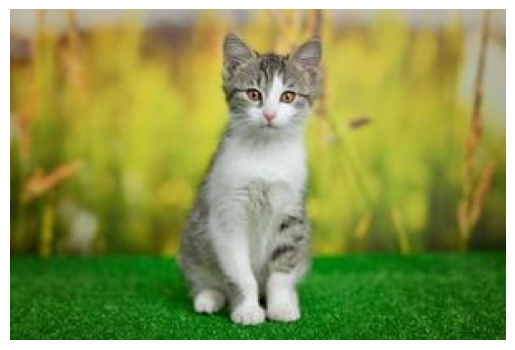

In [93]:
import matplotlib.pyplot as plt
plt.imshow(im)
plt.axis('off') # Hide axes for a cleaner display
plt.show()

In [94]:
# XGB
image = process_img(im)
y_pred = xgb_classifier.predict([image])
print(categories[y_pred[0]])

cats


In [95]:
# SVC
image = process_img(im)
y_pred = svc_classifier.predict([image])
print(categories[y_pred[0]])

dogs
